# Análisis Exploratorio de Datos de Pedidos de Supermercado en Instacart

**Autor:** Daniel Osvaldo Cruz Martínez  
**Perfil:** Próximo egresado de la Licenciatura en Administración de las Organizaciones  
**Institución:** Universidad de Guadalajara (CUGDL - Sistema Virtual) | Período: 2024A - 2027B  
**Enfoque Profesional:** Inteligencia de Negocios (BI), Análisis de Datos y Estrategia Organizacional  

---

### Introducción del Proyecto
Este proyecto forma parte de mi **portafolio profesional** orientado a la inserción laboral como Analista de Datos / Business Intelligence. Presenta un **Análisis Exploratorio de Datos (EDA)** utilizando **Python**, **SQL (SQLite)** y **Pandas** sobre la base de datos masiva de **Instacart**, la cual contiene más de 3.4 millones de registros de compras de supermercado.

**Objetivo:** Mapear la estructura del catálogo, auditar el comportamiento de compra de los usuarios y extraer estadísticas clave de negocio que sirvan como base para futuros tableros interactivos en Power BI y Tableau.


In [10]:
import sqlite3
import pandas as pd

# 1. Establecer la conexión con el archivo de la base de datos de Instacart
conexion = sqlite3.connect('instacart.sqlite')

# 2. Definir la consulta SQL como una cadena de texto de Python
consulta_sql = "SELECT * FROM products LIMIT 10;"

# 3. Usar Pandas para ejecutar la consulta directamente en el archivo y traer los datos
df_productos = pd.read_sql_query(consulta_sql, conexion)

# 4. Mostrar la tabla resultante en la pantalla de Jupyter
display(df_productos)

# 5. Cerrar la conexión para liberar la memoria del disco duro
conexion.close()


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
5,6,Dry Nose Oil,11,11
6,7,Pure Coconut Water With Orange,98,7
7,8,Cut Russet Potatoes Steam N' Mash,116,1
8,9,Light Strawberry Blueberry Yogurt,120,16
9,10,Sparkling Orange Juice & Prickly Pear Beverage,115,7


## Paso 1: Averiguar cuántas tablas hay y cómo se llaman

Vamos a pedirle a Python que le pregunte a la base de datos la lista de todas sus tablas.

In [11]:
import sqlite3
import pandas as pd

conexion = sqlite3.connect('instacart.sqlite')

# Query para listar las tablas del sistema
query_tablas = "SELECT name FROM sqlite_master WHERE type='table';"
df_tablas = pd.read_sql_query(query_tablas, conexion)

display(df_tablas)
conexion.close()


,name
0,orders
1,products
2,order_products_prior


## Paso 2: Medir dimensiones (¿Cuántas filas tiene cada una?)


In [12]:
import sqlite3
import pandas as pd

conexion = sqlite3.connect('instacart.sqlite')

# Queries para contar las filas de cada tabla
q_orders = "SELECT COUNT(*) AS total_filas_orders FROM orders;"
q_products = "SELECT COUNT(*) AS total_filas_products FROM products;"
q_prior = "SELECT COUNT(*) AS total_filas_prior FROM order_products_prior;"

# Ejecutar y mostrar cada una
display(pd.read_sql_query(q_orders, conexion))
display(pd.read_sql_query(q_products, conexion))
display(pd.read_sql_query(q_prior, conexion))

conexion.close()


,total_filas_orders
0,3421083


,total_filas_products
0,49688


,total_filas_prior
0,32434489


* **orders:**     ¡Más de 3.4 millones de pedidos! (3,421,083)
* **products:**   Casi 50 mil productos diferentes en el catálogo (49,688).
* **order_products_prior:**   ¡Un monstruo de 32.4 millones de filas! (32,434,489). *Cada fila es un producto metido dentro de un carrito de compras.*

________________________________________________________________________________________________________________________________________________

## Paso 3: Explorar las columnas y rangos de la tabla orders

Ahora que ya sabemos que la tabla orders tiene 3.4 millones de filas, vamos a aplicar el '''LIMIT 5''' para entender qué columnas tiene y qué significan sus datos.

In [13]:
import sqlite3
import pandas as pd

conexion = sqlite3.connect('instacart.sqlite')

# Traer solo 5 filas para inspeccionar la estructura de 'orders'
query_estructura_orders = "SELECT * FROM orders LIMIT 5;"
df_estructura = pd.read_sql_query(query_estructura_orders, conexion)

display(df_estructura)
conexion.close()


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


___________________________________________________________________________________________________________________________________________________

**Analicemos rápidamente qué significan las columnas clave DE LA TABLA ORDERS:**

```order_id```: El identificador único de cada pedido.

```user_id```: El número único que identifica a cada cliente (el que nos servirá para saber cuántos usuarios distintos hay).

```order_number```: El número de pedido de ese cliente específico (por ejemplo, el usuario 1 ya lleva 5 pedidos en tu muestra).

```order_dow```: El día de la semana (Day of Week) en el que se hizo la compra (números del 0 al 6).

```order_hour_of_day```: La hora exacta del día en que se realizó el pedido (de 0 a 23 horas).


________________________________________________________________________________________________________________________________________________________________

## Paso 4: Respondiendo a dos preguntas fundamentales. 

### ¿Cuántos productos distintos hay? ¿cuántos usuarios distintos hay?

Ahora que ya conocemos las columnas y que comprobamos que la tabla ```products``` tiene la columna ```product_id``` y la tabla ```orders``` tiene la columna ```user_id```,  todo está listo para ejecutar las consultas de ambas preguntas .

In [14]:
import sqlite3
import pandas as pd

conexion = sqlite3.connect('instacart.sqlite')

# 1. Query para contar productos distintos en la tabla 'products'
q_prod_unicos = "SELECT COUNT(DISTINCT product_id) AS total_productos_distintos FROM products;"
df_prod_unicos = pd.read_sql_query(q_prod_unicos, conexion)

# 2. Query para contar usuarios distintos en la tabla 'orders'
q_user_unicos = "SELECT COUNT(DISTINCT user_id) AS total_usuarios_distintos FROM orders;"
df_user_unicos = pd.read_sql_query(q_user_unicos, conexion)

# Mostrar ambos resultados de forma limpia
print("Respuesta a pregunta 1:")
display(df_prod_unicos)

print("\nRespuesta a pregunta 2:")
display(df_user_unicos)

conexion.close()


Respuesta a pregunta 1:


,total_productos_distintos
0,49688



Respuesta a pregunta 2:


,total_usuarios_distintos
0,206209


 ## **total_productos_distintos =** *49,688* ________________**total_usuarios_distintos =** *206,209*  

_________________________________________________________________________________________________________________________________________________


# Pao 5. Estadísticas de Comportamiento de Compra **```(orders)```**

Vamos a pedirle a la base de datos que analice los 3.4 millones de registros para descubrir:  

**1. El rango de horas en que compra la gente (mínima y máxima).**

**2. El promedio de la hora del día en la que se hacen los pedidos.**

**3. El rango de días de la semana en que operan.**

In [15]:
import sqlite3
import pandas as pd

conexion = sqlite3.connect('instacart.sqlite')

# Query con funciones estadísticas básicas: MIN, MAX y AVG
query_estadisticas_orders = """
SELECT 
    MIN(order_hour_of_day) AS hora_mas_temprana,
    MAX(order_hour_of_day) AS hora_mas_tardia,
    AVG(order_hour_of_day) AS hora_promedio_compra,
    MIN(order_dow) AS dia_minimo,
    MAX(order_dow) AS dia_maximo
FROM orders;
"""

df_stats_orders = pd.read_sql_query(query_estadisticas_orders, conexion)
display(df_stats_orders)

conexion.close()


,hora_mas_temprana,hora_mas_tardia,hora_promedio_compra,dia_minimo,dia_maximo
0,0,23,13.452015,0,6


___________________________________________________________________________________________________________________
**-Rango de horas: Va desde las 0 hasta las 23 horas.** Significa que el supermercado opera las 24 horas del día.

**-Hora promedio de compra: Es 13.45 (aproximadamente la 1:30 PM).** Esto nos indica de golpe que la gran masa de pedidos se concentra al mediodía y en las primeras horas de la tarde, no por la noche ni en la madrugada.

**-Rango de días de la semana (order_dow): Va de 0 a 6.** 

**DIA MINIMO, MIN(order_dow):** ¿Cuál es el número de día más chico registrado?. El motor revisa la columna, ve números del 0 al 6, devuelve el 0 (que corresponde al Domingo).

**DIA MAXIMO, MAX(order_dow):** ¿Cuál es el número de día más grande?. El motor ve que el número más alto es el 6 (que corresponde al Sábado). La tabla estadística está diciendo: "En este negocio se registran pedidos desde el día 0 hasta el día 6".

________________________________________________________________________________________________________________________________________________

## Paso 6. Análisis de Distribución (primera visualización)

Para entender verdaderamente a qué hora prefiere comprar la gente , necesitamos agrupar los datos y hacer un gráfico. 
Vamos a contar cuántos pedidos hay por cada hora del día usando GROUP BY y lo graficaremos directamente en Jupyter Lab usando la librería matplotlib.




In [17]:
%pip install matplotlib


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------- ----------------------- 3.9/9.5 MB 25.1 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 27.3 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 23.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 29.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 37.3 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\danie\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


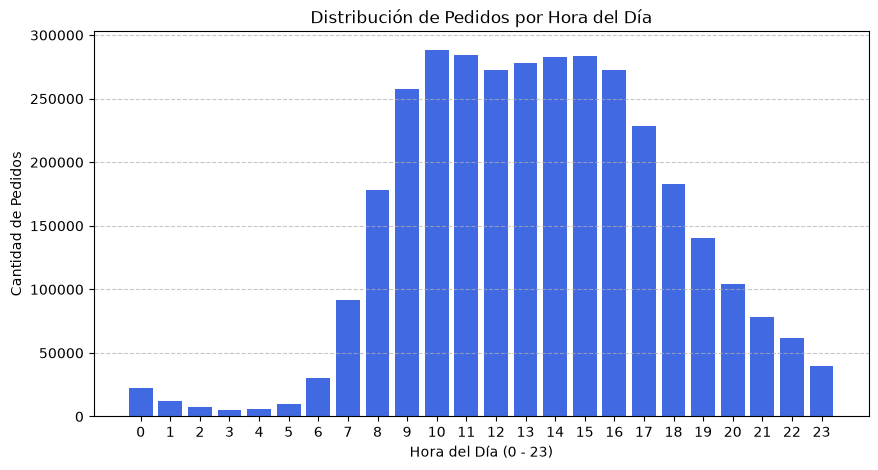

In [19]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conexion = sqlite3.connect('instacart.sqlite')

# 1. Agrupar el total de pedidos por hora del día
query_horas = """
SELECT order_hour_of_day, COUNT(*) AS total_pedidos
FROM orders
GROUP BY order_hour_of_day
ORDER BY order_hour_of_day;
"""
df_horas = pd.read_sql_query(query_horas, conexion)

# 2. Cerrar la conexión
conexion.close()

# 3. CREAR LA VISUALIZACIÓN (Gráfico de barras)
plt.figure(figsize=(10, 5))
plt.bar(df_horas['order_hour_of_day'], df_horas['total_pedidos'], color='royalblue')
plt.title('Distribución de Pedidos por Hora del Día')
plt.xlabel('Hora del Día (0 - 23)')
plt.ylabel('Cantidad de Pedidos')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico en Jupyter
plt.show()


La actividad arranca fuerte a las 9 AM, se mantiene en un pico masivo e impresionante entre las 10 AM y las 4 PM (16 horas) con casi 300,000 pedidos por hora, y cae casi a cero entre la 1 AM y las 5 AM. 

__________________________________________________________________________________________________________________________________________________
## Paso 7. ¿Cuántas compras se hacen por día de la semana?
### Order_dow ; day of week

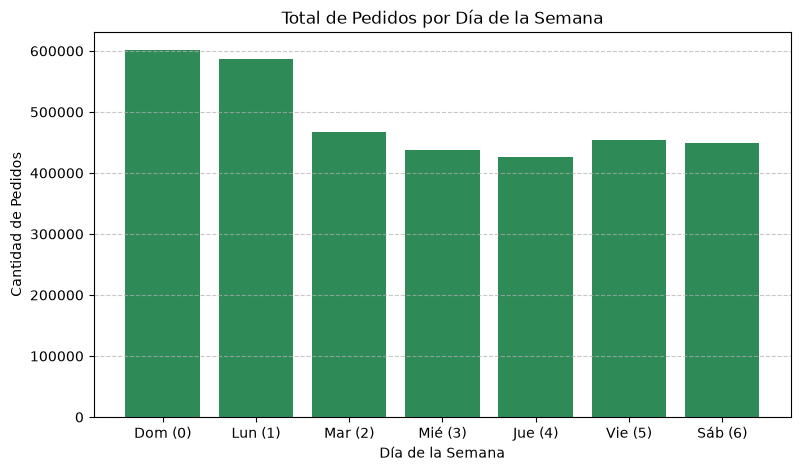

,order_dow,total_pedidos
0,0,600905
1,1,587478
2,2,467260
3,3,436972
4,4,426339
5,5,453368
6,6,448761


In [20]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conexion = sqlite3.connect('instacart.sqlite')

# 1. Agrupar el total de pedidos por día de la semana (order_dow)
query_dias = """
SELECT order_dow, COUNT(*) AS total_pedidos
FROM orders
GROUP BY order_dow
ORDER BY order_dow;
"""
df_dias = pd.read_sql_query(query_dias, conexion)
conexion.close()

# 2. CREAR LA VISUALIZACIÓN CORREGIDA
plt.figure(figsize=(9, 5))
plt.bar(df_dias['order_dow'], df_dias['total_pedidos'], color='seagreen') 
plt.title('Total de Pedidos por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Cantidad de Pedidos')  # Corregido: ya no dice "en millones"
plt.xticks(range(0, 7), ['Dom (0)', 'Lun (1)', 'Mar (2)', 'Mié (3)', 'Jue (4)', 'Vie (5)', 'Sáb (6)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()
display(df_dias)
